In [30]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    log_loss,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.inspection import permutation_importance

# Model Interpretation and Error Analysis

This notebook explains how the selected HistGradientBoosting model makes
predictions and where it makes mistakes.

The analysis includes:

- Validation performance
- Feature importance
- False-positive and false-negative analysis
- Device and placement performance
- Time-based performance
- Popularity and volume bias analysis
- Model limitations

The saved model and validation data are loaded so the analysis can be completed
without retraining the model.

In [31]:
processed_data_path = Path("../data/processed")

print(processed_data_path.resolve())

/Users/kamakshiilapavuluri/avazu_ctr_prediction/data/processed


In [32]:
# define the files

X_validation_path = processed_data_path / "X_validation.parquet"
y_validation_path = processed_data_path / "y_validation.parquet"
model_path = processed_data_path / "hist_gradient_model.pkl"

In [8]:
print(X_validation_path.exists())
print(y_validation_path.exists())
print(model_path.exists())

True
True
True


In [33]:
# Load the saved model
hist_model = joblib.load(
    model_path
)

print("Model loaded successfully")
print(hist_model)


Model loaded successfully
HistGradientBoostingClassifier(max_depth=8, random_state=42)


## Selected Model and Validation Data

The previously trained HistGradientBoosting model is loaded from the processed
data folder.

The validation dataset is also loaded. This dataset was not used to train the
model, so it can be used to study how the model performs on unseen records.

The validation feature count is checked against the number of features expected
by the model. The feature names and order must match the training data.

In [34]:
# Load validation data
X_validation = pd.read_parquet(
    X_validation_path
)

y_validation_data = pd.read_parquet(
    y_validation_path
)

print("Validation features:", X_validation.shape)
print("Validation target:", y_validation_data.shape)

Validation features: (6064345, 26)
Validation target: (6064345, 1)


In [35]:
# target may load as a one-column DataFrame. Convert it into a Series:
if isinstance(y_validation_data, pd.DataFrame):
    y_validation = y_validation_data.iloc[:, 0]
else:
    y_validation = y_validation_data

print("Target shape:", y_validation.shape)
print(y_validation.head())

Target shape: (6064345,)
0    0
1    0
2    1
3    0
4    0
Name: click, dtype: int64


In [28]:
# validation columns must match the columns used during model training.

print("Validation columns:")
print(X_validation.columns.tolist())

Validation columns:
['C1', 'banner_pos', 'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'C19', 'C21', 'day', 'hour_of_day', 'day_of_week', 'is_weekend', 'device_id_freq', 'device_ip_freq', 'app_id_freq', 'device_model_freq', 'site_domain_freq', 'site_id_freq', 'C14_freq', 'app_domain_freq', 'C17_freq', 'C20_freq', 'site_category_freq', 'app_category_freq', 'time_period_freq']


In [36]:
# Check the number of model features:

print(
    "Number of validation features:",
    X_validation.shape[1]
)

if hasattr(hist_model, "n_features_in_"):
    print(
        "Number expected by model:",
        hist_model.n_features_in_
    )

Number of validation features: 26
Number expected by model: 26


In [38]:
# If feature names were saved by the model:
if hasattr(hist_model, "feature_names_in_"):
    print(
        "Model feature names:",
        hist_model.feature_names_in_
    )

Model feature names: ['C1' 'banner_pos' 'device_type' 'device_conn_type' 'C15' 'C16' 'C18'
 'C19' 'C21' 'day' 'hour_of_day' 'day_of_week' 'is_weekend'
 'device_id_freq' 'device_ip_freq' 'app_id_freq' 'device_model_freq'
 'site_domain_freq' 'site_id_freq' 'C14_freq' 'app_domain_freq' 'C17_freq'
 'C20_freq' 'site_category_freq' 'app_category_freq' 'time_period_freq']


In [39]:
# Predict click probabilities
validation_probabilities = hist_model.predict_proba(
    X_validation
)[:, 1]

validation_probabilities[:10]

array([0.14562187, 0.11165592, 0.22638195, 0.19789662, 0.08131247,
       0.0960983 , 0.08219807, 0.29689388, 0.08219807, 0.20797839])

## Classification Threshold

The model produces a probability between 0 and 1 for every impression.

A threshold is required to convert the probability into a final click or
no-click prediction.

A threshold of 0.15 was selected because it provided the best balance between
precision and recall during threshold testing.

- Probability greater than or equal to 0.15: predicted click
- Probability below 0.15: predicted no click

The default threshold of 0.50 was not selected because it produced very low
recall and missed many actual clicks.

In [40]:
# Use the selected threshold
threshold = 0.15

validation_predictions = (
    validation_probabilities >= threshold
).astype(int)

In [41]:
# Check the first predictions:
print(
    "Probabilities:",
    validation_probabilities[:10]
)

print(
    "Predictions:",
    validation_predictions[:10]
)

Probabilities: [0.14562187 0.11165592 0.22638195 0.19789662 0.08131247 0.0960983
 0.08219807 0.29689388 0.08219807 0.20797839]
Predictions: [0 0 1 1 0 0 0 1 0 1]


In [42]:
# Recalculate the model metrics

model_log_loss = log_loss(
    y_validation,
    validation_probabilities
)

model_roc_auc = roc_auc_score(
    y_validation,
    validation_probabilities
)

model_pr_auc = average_precision_score(
    y_validation,
    validation_probabilities
)

model_precision = precision_score(
    y_validation,
    validation_predictions
)

model_recall = recall_score(
    y_validation,
    validation_predictions
)

model_f1 = f1_score(
    y_validation,
    validation_predictions
)

In [43]:
# Create a result table
metric_results = pd.DataFrame({
    "Metric": [
        "Log Loss",
        "ROC-AUC",
        "PR-AUC",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value": [
        model_log_loss,
        model_roc_auc,
        model_pr_auc,
        model_precision,
        model_recall,
        model_f1
    ]
})

metric_results

,Metric,Value
0,Log Loss,0.395350
1,ROC-AUC,0.677061
2,PR-AUC,0.289311
3,Precision,0.228716
4,Recall,0.605777
5,F1 Score,0.332060


## Validation Performance Interpretation

The HistGradientBoosting model achieved a Log Loss of 0.39535.

Log Loss measures the quality of predicted click probabilities. Lower values are
better because they indicate that the predicted probabilities are closer to the
actual outcomes.

The ROC-AUC score was 0.67706. This indicates that the model has a useful, but
not perfect, ability to rank clicked impressions above non-clicked impressions.

The PR-AUC score was 0.28931. PR-AUC focuses on the click class and is useful
because clicks are less common than non-clicks.

At the selected threshold of 0.15:

- Precision was 0.22872
- Recall was 0.60578
- F1 score was 0.33206

The precision result means that approximately 22.9% of predicted clicks were
actual clicks.

The recall result means that the model identified approximately 60.6% of all
actual clicks.

The selected threshold favors finding more actual clicks, but it also produces
a larger number of false-positive predictions.

# Understand which features are important


In [44]:
# use a smaller sample
importance_sample_size = min(
    20_000,
    len(X_validation)
)

importance_indices = X_validation.sample(
    n=importance_sample_size,
    random_state=42
).index

X_importance = X_validation.loc[
    importance_indices
]

y_importance = y_validation.loc[
    importance_indices
]

In [45]:
# Calculate feature importance:
importance_result = permutation_importance(
    hist_model,
    X_importance,
    y_importance,
    scoring="roc_auc",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

In [46]:
# Create a table:
feature_importance = pd.DataFrame({
    "Feature": X_importance.columns,
    "Importance": importance_result.importances_mean
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,Feature,Importance
0,C21,0.047810
1,site_domain_freq,0.021053
2,site_id_freq,0.019240
3,app_category_freq,0.012568
4,app_id_freq,0.012165
5,C17_freq,0.007611
6,device_id_freq,0.006768
7,C19,0.005862
8,device_ip_freq,0.005399
9,C20_freq,0.004374


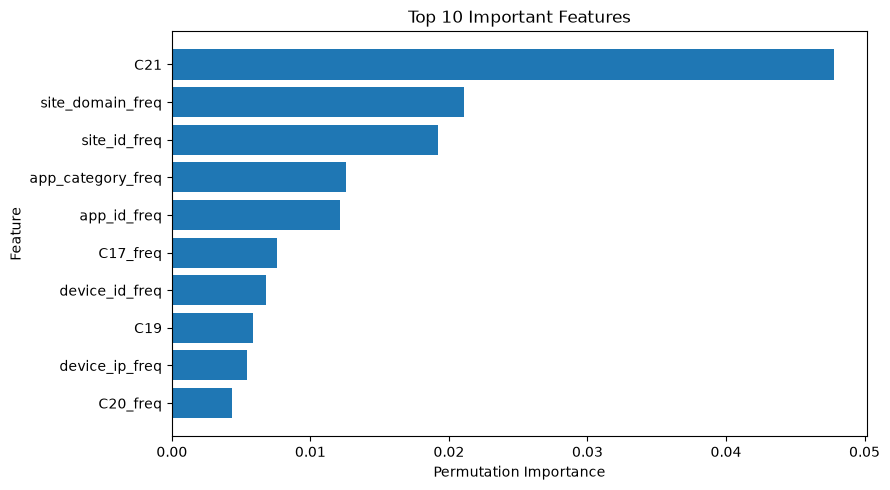

In [47]:
# Plot the top 10:
top_features = feature_importance.head(10)

plt.figure(figsize=(9, 5))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

Overall interpretation

* The model mainly depends on C21.
* Website-related features such as site_domain_freq and site_id_freq are also highly useful.
* App-related features have moderate influence.
* Device-related features have comparatively lower influence.
* Frequency encoding appears to be useful because many important features end with _freq.
* Feature importance does not mean that a feature causes a click. It only shows how much the trained model uses that feature for prediction.

# Analyze false positives and false negatives

In [48]:
# Create one DataFrame containing the actual result, probability and prediction.
error_analysis = X_validation.copy()

error_analysis["actual_click"] = (
    y_validation.values
)

error_analysis["predicted_probability"] = (
    validation_probabilities
)

error_analysis["predicted_click"] = (
    validation_predictions
)

In [49]:
# Create error categories:
conditions = [
    (
        (error_analysis["actual_click"] == 1) &
        (error_analysis["predicted_click"] == 1)
    ),

    (
        (error_analysis["actual_click"] == 0) &
        (error_analysis["predicted_click"] == 0)
    ),

    (
        (error_analysis["actual_click"] == 0) &
        (error_analysis["predicted_click"] == 1)
    ),

    (
        (error_analysis["actual_click"] == 1) &
        (error_analysis["predicted_click"] == 0)
    )
]

labels = [
    "True Positive",
    "True Negative",
    "False Positive",
    "False Negative"
]

error_analysis["prediction_result"] = np.select(
    conditions,
    labels,
    default="Unknown"
)

In [50]:
# Count each type:
error_analysis[
    "prediction_result"
].value_counts()

prediction_result
True Negative     3318732
False Positive    1843288
True Positive      546608
False Negative     355717
Name: count, dtype: int64

## False-Positive and False-Negative Analysis

The confusion matrix shows the number of correct and incorrect classifications.

- True positives: 546,608
- True negatives: 3,318,732
- False positives: 1,843,288
- False negatives: 355,717

A false positive occurs when the model predicts a click, but no click occurs.

False positives may cause an advertising platform to rank, display, or bid on
impressions that do not generate clicks.

A false negative occurs when the model predicts no click, but the user actually
clicks.

False negatives represent missed click opportunities.

The model produced more false positives than false negatives. This is consistent
with the selected threshold of 0.15, which was chosen to improve recall.

Using a lower threshold identifies more real clicks, but it also classifies more
non-clicks as clicks.

In [51]:
# Create a simple table:
error_counts = (
    error_analysis["prediction_result"]
    .value_counts()
    .reset_index()
)

error_counts.columns = [
    "Prediction_Result",
    "Count"
]

error_counts

,Prediction_Result,Count
0,True Negative,3318732
1,False Positive,1843288
2,True Positive,546608
3,False Negative,355717


In [52]:
# Confusion matrix
confusion = confusion_matrix(
    y_validation,
    validation_predictions
)

confusion

array([[3318732, 1843288],
       [ 355717,  546608]])

In [53]:
# Extract the values:
true_negative, false_positive, false_negative, true_positive = (
    confusion.ravel()
)

print("True Negatives:", true_negative)
print("False Positives:", false_positive)
print("False Negatives:", false_negative)
print("True Positives:", true_positive)

True Negatives: 3318732
False Positives: 1843288
False Negatives: 355717
True Positives: 546608


In [54]:
# Examine false positives
false_positives = error_analysis[
    error_analysis["prediction_result"]
    == "False Positive"
].copy()

print(
    "Number of false positives:",
    len(false_positives)
)

Number of false positives: 1843288


In [56]:
# Examine false negatives
false_negatives = error_analysis[
    error_analysis["prediction_result"]
    == "False Negative"
].copy()

print(
    "Number of false negatives:",
    len(false_negatives)
)

Number of false negatives: 355717


In [57]:
# Compare false-positive and false-negative feature averages
important_columns = feature_importance[
    "Feature"
].head(10).tolist()

important_columns

['C21',
 'site_domain_freq',
 'site_id_freq',
 'app_category_freq',
 'app_id_freq',
 'C17_freq',
 'device_id_freq',
 'C19',
 'device_ip_freq',
 'C20_freq']

In [58]:
error_feature_comparison = (
    error_analysis.groupby(
        "prediction_result"
    )[important_columns]
    .mean()
    .T
)

error_feature_comparison

prediction_result,False Negative,False Positive,True Negative,True Positive
C21,155.991673,54.384294,149.634315,48.849938
site_domain_freq,0.183331,0.137289,0.194653,0.118049
site_id_freq,0.171753,0.122369,0.184042,0.099770
app_category_freq,0.500324,0.532680,0.434666,0.571547
app_id_freq,0.429472,0.482698,0.361786,0.532625
C17_freq,0.010263,0.013997,0.012305,0.012671
device_id_freq,0.720462,0.643456,0.702319,0.696874
C19,162.244124,261.798389,180.456273,253.234556
device_ip_freq,0.000176,0.000121,0.000143,0.000101
C20_freq,0.218391,0.257658,0.200922,0.264933


## Comparing Error Patterns

The average values of the most important features were compared across:

- True positives
- True negatives
- False positives
- False negatives

This helps identify whether certain feature patterns appear more frequently in
specific error groups.

For example, differences in site frequency, application frequency, or anonymous
ad-related features may show where the model is more likely to overpredict or
underpredict clicks.

These comparisons show associations only. They do not prove that a feature
directly caused the error.

In [59]:
# Create a reusable segment-evaluation function
def evaluate_by_segment(
    data,
    segment_column,
    minimum_records=100
):
    results = []

    for segment_value, group in data.groupby(
        segment_column
    ):
        if len(group) < minimum_records:
            continue

        actual = group["actual_click"]
        probability = group[
            "predicted_probability"
        ]

        prediction = group[
            "predicted_click"
        ]

        result = {
            "Segment": segment_value,
            "Records": len(group),
            "Actual_CTR": actual.mean(),
            "Average_Predicted_CTR": probability.mean(),
            "Precision": precision_score(
                actual,
                prediction,
                zero_division=0
            ),
            "Recall": recall_score(
                actual,
                prediction,
                zero_division=0
            )
        }

        # ROC-AUC requires both classes
        if actual.nunique() == 2:
            result["ROC_AUC"] = roc_auc_score(
                actual,
                probability
            )
        else:
            result["ROC_AUC"] = np.nan

        results.append(result)

    return pd.DataFrame(results)

In [60]:
# Evaluate by device type
device_results = evaluate_by_segment(
    error_analysis,
    "device_type"
)

device_results

,Segment,Records,Actual_CTR,Average_Predicted_CTR,Precision,Recall,ROC_AUC
0,0,294481,0.213756,0.182831,0.232510,0.650118,0.562119
1,1,5678076,0.146178,0.156602,0.229503,0.602071,0.682050
2,4,78921,0.103585,0.143411,0.160865,0.639388,0.650802
3,5,12836,0.092630,0.130557,0.184244,0.615643,0.719962


## Device Segment Performance

Model performance was evaluated separately for each device type.

The results show that the model does not perform equally across all device
groups.

Device type 5 had the highest ROC-AUC, approximately 0.720.

Device type 0 had the lowest ROC-AUC, approximately 0.562.

The ROC-AUC difference between the best and worst device segments was
approximately 0.158.

This difference does not automatically prove unfair bias. However, it indicates
that the model learns stronger click patterns for some device groups than for
others.

Device groups with lower performance should be investigated for:

- Fewer training records
- Different click behavior
- Missing explanatory features
- Different distributions between training and validation data

In [61]:
# Evaluate by banner position
banner_results = evaluate_by_segment(
    error_analysis,
    "banner_pos"
)

banner_results

,Segment,Records,Actual_CTR,Average_Predicted_CTR,Precision,Recall,ROC_AUC
0,0,4236055,0.138994,0.139954,0.220857,0.517050,0.671712
1,1,1817844,0.171258,0.198854,0.239045,0.772579,0.685317
2,2,2049,0.089800,0.142437,0.143022,0.673913,0.658468
3,3,819,0.024420,0.174577,0.009579,0.250000,0.213986
4,4,837,0.197133,0.113661,0.246575,0.109091,0.518475
5,5,304,0.180921,0.210011,0.161677,0.490909,0.506718
6,7,6437,0.278701,0.171322,0.402608,0.826087,0.654085


## Banner-Position Performance

The model was evaluated separately for each banner position.

For every position, the analysis compared:

- Number of impressions
- Actual CTR
- Average predicted CTR
- Precision
- Recall
- ROC-AUC

Differences between actual CTR and predicted CTR help identify whether the model
overpredicts or underpredicts clicks for a specific placement.

Segments with very few records should be interpreted carefully because their
metrics may be unstable.

In [62]:
# Evaluate by time segment
print(
    [
        column
        for column in X_validation.columns
        if "hour" in column.lower()
        or "day" in column.lower()
        or "time" in column.lower()
    ]
)

['day', 'hour_of_day', 'day_of_week', 'time_period_freq']


In [63]:
# For hour_of_day

if "hour_of_day" in error_analysis.columns:

    error_analysis["time_segment"] = pd.cut(
        error_analysis["hour_of_day"],
        bins=[-1, 5, 11, 17, 23],
        labels=[
            "Night",
            "Morning",
            "Afternoon",
            "Evening"
        ]
    )

    time_results = evaluate_by_segment(
        error_analysis,
        "time_segment"
    )

    display(time_results)

,Segment,Records,Actual_CTR,Average_Predicted_CTR,Precision,Recall,ROC_AUC
0,Night,879758,0.159382,0.159864,0.220775,0.579284,0.647383
1,Morning,2238600,0.142295,0.150240,0.221263,0.549917,0.660473
2,Afternoon,1938526,0.153635,0.155480,0.238056,0.604272,0.681386
3,Evening,1007461,0.144661,0.176348,0.232429,0.756436,0.734908


## Time-of-Day Performance

The validation data was divided into four time periods:

- Night
- Morning
- Afternoon
- Evening

The model performed best during the evening, with ROC-AUC of approximately
0.735.

Morning performance was lower, with ROC-AUC of approximately 0.660.

Recall was also highest during the evening.

This suggests that click behavior during evening hours may contain stronger or
more predictable patterns.

Differences across time periods may also reflect changes in user activity,
applications, sites, device usage, or ad inventory.

# Evaluate Popularity and Volume Bias

The frequency-encoded features are divided into three approximately equal
groups:

- Low frequency
- Medium frequency
- High frequency

The purpose is to determine whether the model performs better for frequently
observed devices, popular apps, or high-volume sites.

If the model has much higher ROC-AUC or recall for high-frequency groups than
for low-frequency groups, it may not generalize as well to rare or new
entities.

In [67]:
def create_frequency_band(data, source_column, new_column):

    data[new_column] = pd.qcut(
        data[source_column].rank(method="first"),
        q=3,
        labels=["Low", "Medium", "High"]
    )

### Frequent-Device Analysis

The Avazu dataset does not contain a clearly identified user account ID.

`device_id_freq` is therefore used only as a device or user-frequency proxy.

The analysis compares model performance for low-, medium-, and high-frequency
device groups.

In [68]:
# Check bias toward frequent users or devices
# Avazu does not contain a clean user account ID. device_id is often used as a user/device proxy.

create_frequency_band(
    error_analysis,
    "device_id_freq",
    "device_frequency_group"
)

In [69]:
# Check the result
print(
    error_analysis[
        ["device_id_freq", "device_frequency_group"]
    ].head()
)

   device_id_freq device_frequency_group
0        0.824602                    Low
1        0.824602                    Low
2        0.824602                    Low
3        0.824602                    Low
4        0.824602                    Low


In [70]:
# Count the rows in each group

print(
    error_analysis["device_frequency_group"].value_counts()
)

device_frequency_group
Low       2021449
Medium    2021448
High      2021448
Name: count, dtype: int64


### App-Popularity Analysis

`app_id_freq` represents how frequently an app appeared in the training data.

The analysis checks whether the model performs better for popular apps than for
less frequently observed apps.

In [71]:
# Check bias toward popular apps or ads
if "app_id_freq" in error_analysis.columns:

    create_frequency_band(
        error_analysis,
        "app_id_freq",
        "app_popularity_group"
    )

    app_popularity_results = (
        evaluate_by_segment(
            error_analysis,
            "app_popularity_group"
        )
    )

    display(app_popularity_results)

,Segment,Records,Actual_CTR,Average_Predicted_CTR,Precision,Recall,ROC_AUC
0,Low,2021449,0.112043,0.120914,0.175203,0.466764,0.652565
1,Medium,2021448,0.157580,0.164263,0.251392,0.619243,0.692058
2,High,2021448,0.176753,0.187769,0.243187,0.681892,0.666498


### Ad-Related Popularity Analysis

`C14` is an anonymous Avazu feature.

Its frequency is used only as an ad-related popularity proxy. It should not be
described as a confirmed advertisement ID.

The analysis compares performance across low-, medium-, and high-frequency
`C14` groups.

In [72]:
# For C14_freq
if "C14_freq" in error_analysis.columns:

    create_frequency_band(
        error_analysis,
        "C14_freq",
        "ad_popularity_group"
    )

    ad_popularity_results = (
        evaluate_by_segment(
            error_analysis,
            "ad_popularity_group"
        )
    )

    display(ad_popularity_results)

,Segment,Records,Actual_CTR,Average_Predicted_CTR,Precision,Recall,ROC_AUC
0,Low,2021449,0.133879,0.127635,0.177454,0.409642,0.610979
1,Medium,2021448,0.145930,0.150223,0.225366,0.611977,0.684036
2,High,2021448,0.166567,0.195087,0.264717,0.757991,0.731054


### Site or Publisher-Volume Analysis

`site_id_freq` is used as a proxy for site or publisher volume.

The analysis checks whether the model performs better for high-volume sites
than for rare or low-volume sites.

In [73]:
# Check publisher or site-volume bias
if "site_id_freq" in error_analysis.columns:

    create_frequency_band(
        error_analysis,
        "site_id_freq",
        "site_volume_group"
    )

    site_volume_results = (
        evaluate_by_segment(
            error_analysis,
            "site_volume_group"
        )
    )

    display(site_volume_results)

,Segment,Records,Actual_CTR,Average_Predicted_CTR,Precision,Recall,ROC_AUC
0,Low,2021449,0.148285,0.162598,0.219285,0.660197,0.686000
1,Medium,2021448,0.194348,0.190917,0.271247,0.634609,0.651508
2,High,2021448,0.103743,0.119430,0.174905,0.473981,0.654832


### Campaign-Volume Proxy Analysis

The Avazu dataset does not include a clearly labeled campaign ID.

`C17_freq` is used only as an exploratory campaign or configuration-volume
proxy.

The results must not be presented as a confirmed campaign-level analysis.

In [74]:
# Check campaign-volume proxy
if "C17_freq" in error_analysis.columns:

    create_frequency_band(
        error_analysis,
        "C17_freq",
        "campaign_proxy_volume"
    )

    campaign_proxy_results = (
        evaluate_by_segment(
            error_analysis,
            "campaign_proxy_volume"
        )
    )

    display(campaign_proxy_results)

,Segment,Records,Actual_CTR,Average_Predicted_CTR,Precision,Recall,ROC_AUC
0,Low,2021449,0.122258,0.102998,0.184637,0.291230,0.634363
1,Medium,2021448,0.180609,0.196893,0.242207,0.760211,0.693485
2,High,2021448,0.143509,0.173054,0.230735,0.679388,0.708338


## 11. Summarize Segment Differences

The best- and worst-performing segments are identified using ROC-AUC.

The difference between the highest and lowest segment ROC-AUC values helps
identify groups that may require further investigation.

A performance difference does not automatically prove unfair bias. It may also
be caused by sample size, different click behavior, missing features, or rare
categories.

In [75]:
# Simple bias summary table
def summarize_segments(
    segment_results,
    segment_name
):
    if segment_results.empty:
        return None

    valid_auc = segment_results.dropna(
        subset=["ROC_AUC"]
    )

    if valid_auc.empty:
        return None

    best_row = valid_auc.loc[
        valid_auc["ROC_AUC"].idxmax()
    ]

    worst_row = valid_auc.loc[
        valid_auc["ROC_AUC"].idxmin()
    ]

    return pd.DataFrame({
        "Analysis": [segment_name],
        "Best_Segment": [
            best_row["Segment"]
        ],
        "Best_ROC_AUC": [
            best_row["ROC_AUC"]
        ],
        "Worst_Segment": [
            worst_row["Segment"]
        ],
        "Worst_ROC_AUC": [
            worst_row["ROC_AUC"]
        ],
        "ROC_AUC_Difference": [
            best_row["ROC_AUC"]
            - worst_row["ROC_AUC"]
        ]
    })


In [76]:
device_summary = summarize_segments(
    device_results,
    "Device Type"
)

device_summary

,Analysis,Best_Segment,Best_ROC_AUC,Worst_Segment,Worst_ROC_AUC,ROC_AUC_Difference
0,Device Type,5.0,0.719962,0.0,0.562119,0.157843


# Final Interpretation Summary

## Feature importance

Permutation importance was used to identify which features contributed most to
model ranking performance.

The most important features were those that caused the largest decrease in
ROC-AUC when shuffled.

## Error analysis

False positives represent impressions predicted as clicks where no click
occurred.

False negatives represent actual clicks that the model failed to identify.

The error records and their feature patterns were reviewed to understand where
the model makes mistakes.

## Segment analysis

The model was evaluated across available device types, banner positions, time
periods, and frequency-based popularity groups.

Large differences between segments may indicate that the model performs better
for some groups than others.

## Popularity bias

Device, app, site, and anonymous ad-related frequency features were grouped into
low-, medium-, and high-frequency bands.

If performance is consistently stronger for high-frequency groups, the model
may be biased toward popular or frequently observed entities and may perform
less reliably for rare or new entities.

## Limitations

The dataset does not provide clearly labeled user, campaign, publisher, or
geography fields.

Device ID, site ID, and anonymous Avazu columns were therefore used only as
proxies where appropriate.

The proxy results should not be described as confirmed user-, campaign-,
publisher-, or geography-level findings.